# Cinemate — Recommendation System Exploration

**Dataset**: MovieLens 25M (25M ratings, 162K users, 62K movies + genome tags)  
**Validation**: Cinemate live DB export (real-world sparse dataset)  
**Goal**: Benchmark algorithms, find the best approach, document gaps vs `ml/main.py`

### Why one dataset
ML-25M contains everything needed in a single zip:
- `ratings.csv` — 25M explicit ratings for collaborative filtering
- `genome-scores.csv` — 1,128 relevance-scored tags per movie for content-based filtering  
- `genome-tags.csv` — tag names (`atmospheric`, `twist ending`, `based on true story`, …)
- `links.csv` — TMDB/IMDB IDs per movie (bridges to our DB)
- `movies.csv` — title, year, genre list

The genome tags replace TMDB 5000 as content features — they are denser, pre-computed,  
and better than raw keyword/genre text for cosine similarity.

### Sampling strategy
25M ratings is too large for KNN and GridSearchCV in a notebook.  
We use a **stratified 20% sample** for algorithm comparison and the **full dataset** only for the final tuned SVD.

---
Run top-to-bottom with a fresh kernel. Slow cells are marked `%%time`.

## 0 · Setup

In [2]:
# Uncomment and run once, then comment back out
#!pip install scikit-surprise implicit lightfm matplotlib seaborn joblib psycopg2-binary --break-system-packages

Defaulting to user installation because normal site-packages is not writeable
  Using cached lightfm-1.17.tar.gz (316 kB)
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.6/7.6 MB 1.7 MB/s eta 0:00:00m eta 0:00:010:00:01
  error: subprocess-exited-with-error
  
  × python setup.py bdist_wheel did not run successfully.
  │ exit code: 1
  ╰─> [224 lines of output]
      /usr/lib/python3/dist-packages/setuptools/dist.py:744: SetuptoolsDeprecationWarning: Invalid dash-separated options
      !!
      
              ********************************************************************************
              Usage of dash-separated 'description-file' will not be supported in future
              versions. Please use the underscore name 'description_file' instead.
      
              This deprecation is overdue, please update your project and remove deprecated
              calls to avoid build errors in the future.
      
              See https://set

In [3]:
import warnings, os, re
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import svds
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
import joblib

warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED)

DATA   = Path('data')
MODELS = Path('models')
DATA.mkdir(exist_ok=True)
MODELS.mkdir(exist_ok=True)

plt.style.use('dark_background')
GREEN  = '#00e054'
ORANGE = '#ef9f27'
MUTED  = '#556677'

# Sampling fraction used for slow algorithms (KNN, GridSearchCV)
# Set to 1.0 to use full dataset (takes much longer)
SAMPLE_FRAC = 0.20

print('Environment ready.')

Environment ready.


---
## 1 · Data Loading

### 1.1 MovieLens 25M

Download from https://grouplens.org/datasets/movielens/25m/ (~250 MB zip)  
Extract into `data/ml-25m/`. Expected files:
```
data/ml-25m/
  ratings.csv        25M rows  — userId, movieId, rating (0.5–5.0), timestamp
  movies.csv         62K rows  — movieId, title, genres
  genome-scores.csv  72M rows  — movieId, tagId, relevance (0.0–1.0)
  genome-tags.csv    1128 rows — tagId, tag
  links.csv          62K rows  — movieId, imdbId, tmdbId
```

In [4]:
%%time
ML_DIR = DATA / 'ml-25m'

if not (ML_DIR / 'ratings.csv').exists():
    print('⚠  MovieLens 25M not found.')
    print('   1. Download: https://grouplens.org/datasets/movielens/25m/')
    print('   2. Extract into ml/notebooks/data/ml-25m/')
    raise FileNotFoundError('MovieLens 25M required to run this notebook.')

ratings  = pd.read_csv(ML_DIR / 'ratings.csv',  dtype={'userId': int, 'movieId': int, 'rating': float, 'timestamp': int})
movies   = pd.read_csv(ML_DIR / 'movies.csv',   dtype={'movieId': int})
links    = pd.read_csv(ML_DIR / 'links.csv',    dtype={'movieId': int, 'tmdbId': 'Int64'})
g_tags   = pd.read_csv(ML_DIR / 'genome-tags.csv')

movies['year']       = movies['title'].str.extract(r'\((\d{4})\)').astype('Int64')
movies['genre_list'] = movies['genres'].str.split('|')
movies = movies.merge(links[['movieId','tmdbId']], on='movieId', how='left')

print(f'Ratings  : {len(ratings):>12,}  ({ratings.userId.nunique():,} users × {ratings.movieId.nunique():,} movies)')
print(f'Movies   : {len(movies):>12,}')
print(f'Genome tags: {len(g_tags):>9,} unique tags')
print(f'Rating scale: {ratings.rating.min()} – {ratings.rating.max()} (half-star steps)')
ratings.head(3)

Ratings  :   25,000,095  (162,541 users × 59,047 movies)
Movies   :       62,423
Genome tags:     1,128 unique tags
Rating scale: 0.5 – 5.0 (half-star steps)
CPU times: user 5.14 s, sys: 4.83 s, total: 9.97 s
Wall time: 9.99 s


,userId,movieId,rating,timestamp
0,1,296,5.0,1147880044
1,1,306,3.5,1147868817
2,1,307,5.0,1147868828


In [5]:
%%time
# Load genome scores — 72M rows, takes ~30s
# Result: genome_matrix shape (n_movies_with_genome × 1128)
g_scores = pd.read_csv(ML_DIR / 'genome-scores.csv', dtype={'movieId': int, 'tagId': int, 'relevance': float})

n_genome_movies = g_scores.movieId.nunique()
print(f'Genome scores: {len(g_scores):,} rows covering {n_genome_movies:,} movies')

# Pivot to (movie × tag) matrix — memory ~= 13K movies × 1128 tags × 8 bytes ≈ 117 MB
genome_matrix = g_scores.pivot(index='movieId', columns='tagId', values='relevance')
genome_movie_ids = genome_matrix.index.tolist()  # movieIds that have genome data
print(f'Genome matrix shape: {genome_matrix.shape}')
genome_matrix.iloc[:3, :5]

Genome scores: 15,584,448 rows covering 13,816 movies
Genome matrix shape: (13816, 1128)
CPU times: user 3.41 s, sys: 1.12 s, total: 4.53 s
Wall time: 4.55 s


tagId,1,2,3,4,5
movieId,,,,,
1,0.02875,0.02375,0.06250,0.07575,0.14075
2,0.04125,0.04050,0.06275,0.08275,0.09100
3,0.04675,0.05550,0.02925,0.08700,0.04750


### 1.2 Stratified Sample for Fast Exploration

KNN and GridSearchCV are infeasible on 25M ratings in a notebook.  
We sample `SAMPLE_FRAC` of each user's ratings, keeping the user distribution intact.

In [14]:
%%time
ratings_sample = (
    ratings
    .groupby('userId', group_keys=False)
    .apply(lambda g: g.sample(frac=SAMPLE_FRAC, random_state=SEED) if len(g) >= 5 else g)
    .reset_index(drop=True)
)
print(f'Sample : {len(ratings_sample):,} ratings  '
      f'({ratings_sample.userId.nunique():,} users × {ratings_sample.movieId.nunique():,} movies)')
print(f'Reduction: {1 - len(ratings_sample)/len(ratings):.1%} of data dropped for exploration')

Sample : 4,999,208 ratings  (162,541 users × 39,692 movies)
Reduction: 80.0% of data dropped for exploration
CPU times: user 1min 4s, sys: 3.18 s, total: 1min 8s
Wall time: 1min 8s


### 1.3 Train / Test Split

Temporal split: use the **last 20% of each user's ratings (by timestamp)** as the test set.  
This is more realistic than random split — it simulates recommending movies the user hasn't seen yet.

In [12]:
%%time
train_list, test_list = [], []

for uid, group in ratings_sample.sort_values('timestamp').groupby('userId'):
    n = len(group)
    if n < 5:
        train_list.append(group)
        continue
    cutoff = int(n * 0.8)
    train_list.append(group.iloc[:cutoff])
    test_list.append(group.iloc[cutoff:])

train_df = pd.concat(train_list).reset_index(drop=True)
test_df  = pd.concat(test_list).reset_index(drop=True)

print(f'Train: {len(train_df):,}   Test: {len(test_df):,}')
print(f'Test users covered: {test_df.userId.nunique():,}')

Train: 3,948,516   Test: 1,050,692
Test users covered: 151,412
CPU times: user 29.3 s, sys: 2.32 s, total: 31.6 s
Wall time: 31.9 s


### 1.4 Cinemate DB Export (real-world validation)

Run on your host machine (not inside Docker):
```bash
psql -h localhost -p 5433 -U postgres -d cinemate \
  -c "\COPY (SELECT r.user_id::text, m.tmdb_id, r.score FROM ratings r JOIN movies m ON m.id = r.movie_id) \
  TO 'data/cinemate_ratings.csv' CSV HEADER"

psql -h localhost -p 5433 -U postgres -d cinemate \
  -c "\COPY (SELECT user_id::text, m.tmdb_id, progress_s, updated_at FROM watch_history wh JOIN movies m ON m.id = wh.movie_id) \
  TO 'data/cinemate_watch.csv' CSV HEADER"
```
These are used only in Section 8 (real-world validation). All algorithm comparisons use ML-25M.

In [9]:
cine_ratings, cine_watch = None, None

if (DATA / 'cinemate_ratings.csv').exists():
    cine_ratings = pd.read_csv(DATA / 'cinemate_ratings.csv')
    print(f'Cinemate ratings : {len(cine_ratings):,}  ({cine_ratings.user_id.nunique()} users)')
else:
    print('Cinemate ratings not found — Section 8 will be skipped.')

if (DATA / 'cinemate_watch.csv').exists():
    cine_watch = pd.read_csv(DATA / 'cinemate_watch.csv')
    print(f'Cinemate watch history: {len(cine_watch):,} events')
else:
    print('Cinemate watch history not found — ALS section will be skipped.')

Cinemate ratings not found — Section 8 will be skipped.
Cinemate watch history not found — ALS section will be skipped.


---
## 2 · Exploratory Data Analysis

In [7]:
user_counts  = ratings.groupby('userId').size()
movie_counts = ratings.groupby('movieId').size()

n_users  = ratings.userId.nunique()
n_movies = ratings.movieId.nunique()
sparsity = 1 - len(ratings) / (n_users * n_movies)

print('=== ML-25M Statistics ===')
print(f'Total ratings        : {len(ratings):>12,}')
print(f'Users                : {n_users:>12,}')
print(f'Movies               : {n_movies:>12,}')
print(f'Sparsity             : {sparsity:>11.4%}')
print(f'Cold-start users (<5): {(user_counts < 5).mean():>11.2%}')
print(f'Obscure movies (<10) : {(movie_counts < 10).mean():>11.2%}')
print(f'Mean rating          : {ratings.rating.mean():>12.3f} ± {ratings.rating.std():.3f}')
print(f'Median ratings/user  : {user_counts.median():>12.0f}')
print(f'Median ratings/movie : {movie_counts.median():>12.0f}')
print(f'Movies with genome   : {n_genome_movies:>12,}  ({n_genome_movies/n_movies:.1%} of catalog)')

=== ML-25M Statistics ===
Total ratings        :   25,000,095
Users                :      162,541
Movies               :       59,047
Sparsity             :    99.7395%
Cold-start users (<5):       0.00%
Obscure movies (<10) :      58.80%
Mean rating          :        3.534 ± 1.061
Median ratings/user  :           71
Median ratings/movie :            6
Movies with genome   :       13,816  (23.4% of catalog)


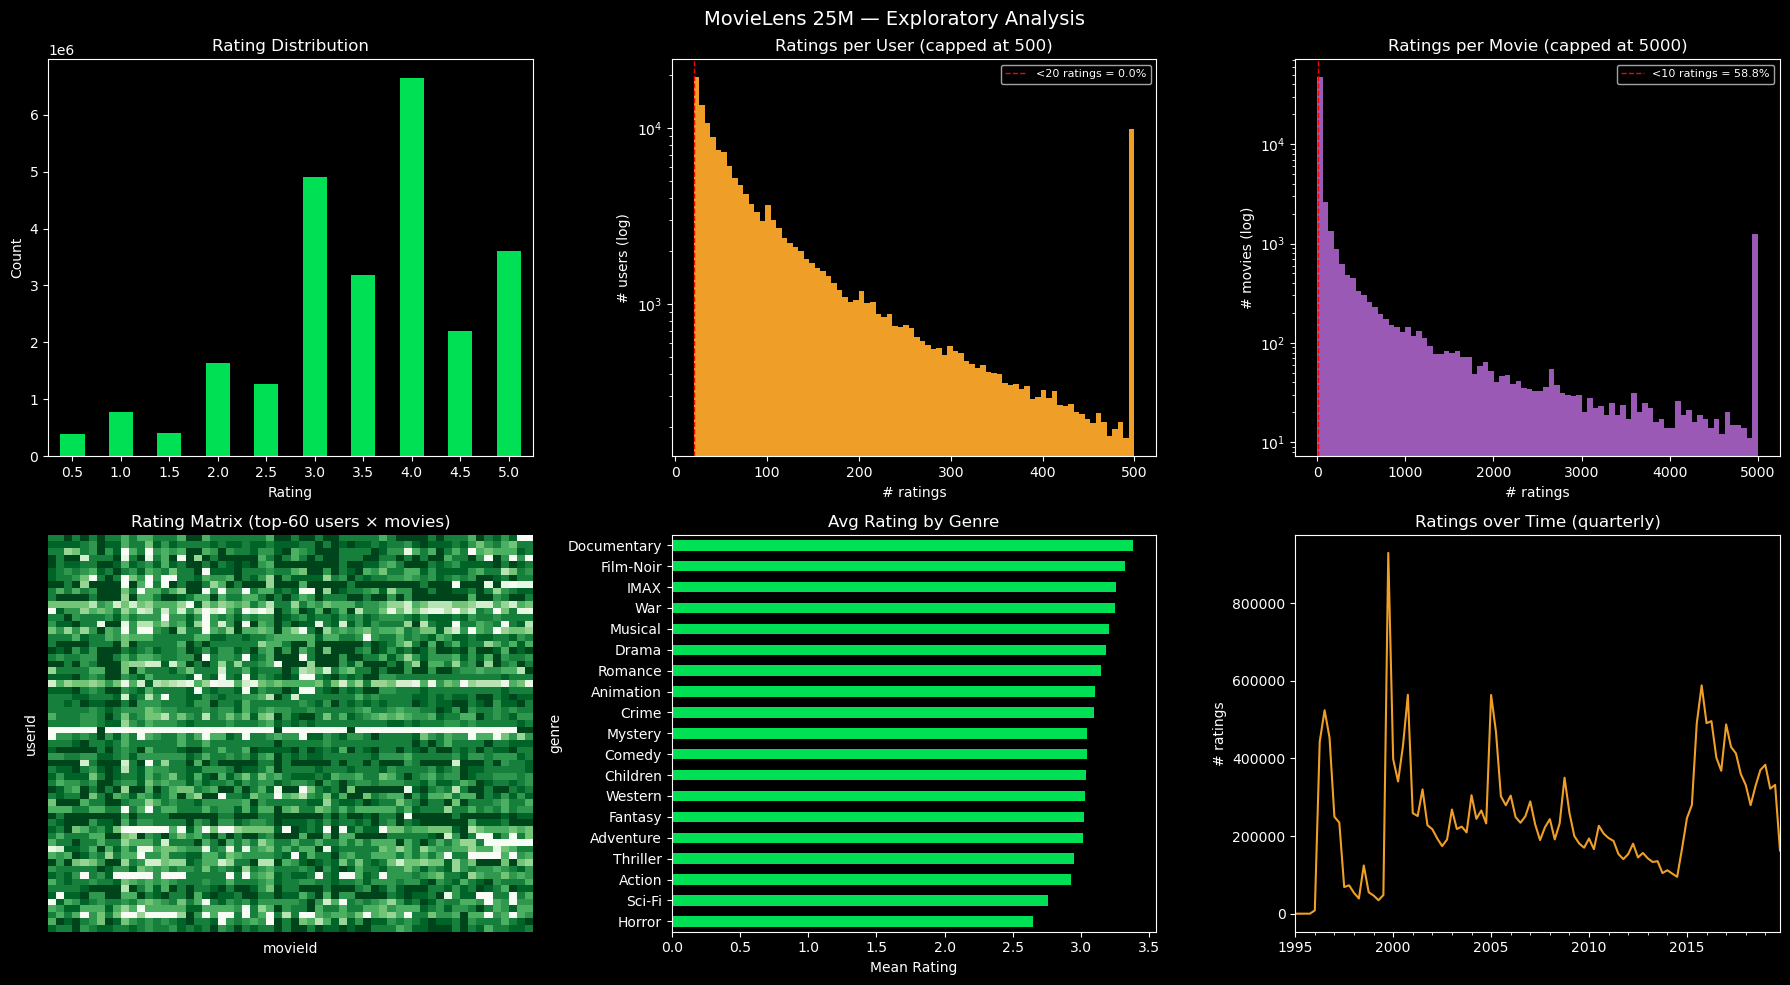

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('MovieLens 25M — Exploratory Analysis', fontsize=14)

# 1. Rating distribution (ML-25M uses half-star steps: 0.5, 1.0, ..., 5.0)
ax = axes[0, 0]
ratings['rating'].value_counts().sort_index().plot.bar(ax=ax, color=GREEN, edgecolor='none')
ax.set_title('Rating Distribution')
ax.set_xlabel('Rating'); ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=0)

# 2. Ratings per user (log scale) — cold-start problem visualised
ax = axes[0, 1]
ax.hist(user_counts.clip(upper=500), bins=80, color=ORANGE, edgecolor='none')
ax.set_title('Ratings per User (capped at 500)')
ax.set_xlabel('# ratings'); ax.set_ylabel('# users (log)')
ax.set_yscale('log')
cold = (user_counts < 20).mean()
ax.axvline(20, color='red', lw=1, ls='--', label=f'<20 ratings = {cold:.1%}')
ax.legend(fontsize=8)

# 3. Ratings per movie — long-tail problem
ax = axes[0, 2]
ax.hist(movie_counts.clip(upper=5000), bins=80, color='#9b59b6', edgecolor='none')
ax.set_title('Ratings per Movie (capped at 5000)')
ax.set_xlabel('# ratings'); ax.set_ylabel('# movies (log)')
ax.set_yscale('log')
rare = (movie_counts < 10).mean()
ax.axvline(10, color='red', lw=1, ls='--', label=f'<10 ratings = {rare:.1%}')
ax.legend(fontsize=8)

# 4. Sparsity heatmap — top 60 users × movies
ax = axes[1, 0]
top_u = user_counts.nlargest(60).index
top_m = movie_counts.nlargest(60).index
sub   = ratings[ratings.userId.isin(top_u) & ratings.movieId.isin(top_m)]
piv   = sub.pivot_table(index='userId', columns='movieId', values='rating').fillna(0)
sns.heatmap(piv, ax=ax, cmap='Greens', cbar=False, xticklabels=False, yticklabels=False)
ax.set_title('Rating Matrix (top-60 users × movies)')

# 5. Average rating per genre
ax = axes[1, 1]
genre_rows = []
for _, row in movies.iterrows():
    mr = ratings[ratings.movieId == row.movieId]['rating']
    if len(mr) == 0: continue
    avg = mr.mean()
    for g in (row.genre_list or []):
        if g != '(no genres listed)':
            genre_rows.append((g, avg))
gr_df = pd.DataFrame(genre_rows, columns=['genre','avg'])
gr_df.groupby('genre')['avg'].mean().sort_values().plot.barh(ax=ax, color=GREEN, edgecolor='none')
ax.set_title('Avg Rating by Genre')
ax.set_xlabel('Mean Rating')

# 6. Ratings over time
ax = axes[1, 2]
ratings['dt'] = pd.to_datetime(ratings['timestamp'], unit='s')
ratings.set_index('dt')['rating'].resample('QE').count().plot(ax=ax, color=ORANGE, lw=1.5)
ax.set_title('Ratings over Time (quarterly)')
ax.set_xlabel(''); ax.set_ylabel('# ratings')

plt.tight_layout()
plt.savefig(MODELS / 'eda.png', dpi=120, bbox_inches='tight')
plt.show()

### 2.1 Genome Tag Distribution

Genome tags are the foundation of content-based filtering in this notebook.  
Understand what they look like before using them.

In [9]:
# Most discriminating tags: highest variance across movies
# High variance → tag distinguishes movies well → useful feature
tag_variance = genome_matrix.var(axis=0).sort_values(ascending=False)
top_tags     = tag_variance.head(20).index
top_tag_names = g_tags.set_index('tagId').loc[top_tags, 'tag'].values

print('Top 20 most discriminating genome tags (highest variance):')
for i, (tid, name) in enumerate(zip(top_tags, top_tag_names)):
    print(f'  {i+1:2d}. {name}  (var={tag_variance[tid]:.4f})')

Top 20 most discriminating genome tags (highest variance):
   1. comedy  (var=0.0802)
   2. action  (var=0.0639)
   3. relationships  (var=0.0583)
   4. horror  (var=0.0577)
   5. tense  (var=0.0575)
   6. independent film  (var=0.0559)
   7. intimate  (var=0.0551)
   8. criterion  (var=0.0549)
   9. drama  (var=0.0544)
  10. violence  (var=0.0543)
  11. murder  (var=0.0539)
  12. suspense  (var=0.0527)
  13. based on a book  (var=0.0523)
  14. funny  (var=0.0491)
  15. dramatic  (var=0.0483)
  16. bleak  (var=0.0478)
  17. loneliness  (var=0.0474)
  18. obsession  (var=0.0470)
  19. family  (var=0.0469)
  20. enigmatic  (var=0.0466)


In [15]:
# Example: what does a movie's genome vector look like?
# Find a well-known movie to inspect
sample_movie = movies[movies.title.str.contains('Fight Club', na=False)].iloc[0]
mid = sample_movie['movieId']

if mid in genome_matrix.index:
    vec  = genome_matrix.loc[mid]
    top5 = vec.nlargest(10)
    top5_names = g_tags.set_index('tagId').loc[top5.index, 'tag'].values
    print(f'Top genome tags for "{sample_movie.title}":')
    for name, rel in zip(top5_names, top5.values):
        bar = '█' * int(rel * 30)
        print(f'  {name:<30} {rel:.3f} {bar}')

Top genome tags for "Fight Club (1999)":
  narrated                       0.989 █████████████████████████████
  plot twist                     0.984 █████████████████████████████
  imdb top 250                   0.983 █████████████████████████████
  violence                       0.981 █████████████████████████████
  cerebral                       0.977 █████████████████████████████
  powerful ending                0.976 █████████████████████████████
  storytelling                   0.975 █████████████████████████████
  great acting                   0.975 █████████████████████████████
  interesting                    0.973 █████████████████████████████
  dark humor                     0.972 █████████████████████████████


---
## 3 · Baseline Models

Every model must beat these, otherwise it adds complexity for nothing.

In [16]:
def rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((np.asarray(y_true) - np.asarray(y_pred)) ** 2)))

def mae(y_true, y_pred):
    return float(np.mean(np.abs(np.asarray(y_true) - np.asarray(y_pred))))

results = []  # accumulates all model results for the final comparison

global_mean = train_df['rating'].mean()

# 1. Global mean
preds = [global_mean] * len(test_df)
results.append({'Model': 'Global mean', 'RMSE': rmse(test_df.rating, preds), 'MAE': mae(test_df.rating, preds)})

# 2. User mean
user_mean = train_df.groupby('userId')['rating'].mean()
preds = test_df['userId'].map(user_mean).fillna(global_mean)
results.append({'Model': 'User mean', 'RMSE': rmse(test_df.rating, preds), 'MAE': mae(test_df.rating, preds)})

# 3. Movie mean
movie_mean = train_df.groupby('movieId')['rating'].mean()
preds = test_df['movieId'].map(movie_mean).fillna(global_mean)
results.append({'Model': 'Movie mean', 'RMSE': rmse(test_df.rating, preds), 'MAE': mae(test_df.rating, preds)})

# 4. Damped mean — Bayesian shrinkage toward global mean (lambda=25)
LAMBDA = 25
mstats = train_df.groupby('movieId')['rating'].agg(['sum','count'])
mstats['damped'] = (mstats['sum'] + LAMBDA * global_mean) / (mstats['count'] + LAMBDA)
preds = test_df['movieId'].map(mstats['damped']).fillna(global_mean)
results.append({'Model': f'Damped mean (λ={LAMBDA})', 'RMSE': rmse(test_df.rating, preds), 'MAE': mae(test_df.rating, preds)})

for r in results:
    print(f"{r['Model']:<35} RMSE={r['RMSE']:.4f}  MAE={r['MAE']:.4f}")

Global mean                         RMSE=1.0572  MAE=0.8304
User mean                           RMSE=0.9826  MAE=0.7508
Movie mean                          RMSE=0.9684  MAE=0.7448
Damped mean (λ=25)                  RMSE=0.9661  MAE=0.7434


> **Expected on ML-25M**: global mean ~1.05, damped mean ~0.90. Any model above 0.90 RMSE is not worth using.

---
## 4 · Collaborative Filtering

All Surprise models run on the **stratified sample** (`SAMPLE_FRAC=0.20`).  
The final tuned SVD is trained on the **full 25M** dataset.

In [17]:
%%time
from surprise import Dataset, Reader, SVD, SVDpp, NMF, KNNBaseline
from surprise.model_selection import cross_validate, GridSearchCV
from surprise.model_selection import train_test_split as surp_split

# ML-25M uses 0.5–5.0 half-star ratings
reader     = Reader(rating_scale=(0.5, 5.0))
data_surp  = Dataset.load_from_df(ratings_sample[['userId','movieId','rating']], reader)
print(f'Surprise dataset: {len(ratings_sample):,} ratings (sample)')

Surprise dataset: 4,999,208 ratings (sample)
CPU times: user 2.57 s, sys: 220 ms, total: 2.79 s
Wall time: 2.8 s


In [18]:
def cv_score(algo, data, cv=5, label=None):
    res  = cross_validate(algo, data, measures=['RMSE','MAE'], cv=cv, verbose=False)
    r, m = float(res['test_rmse'].mean()), float(res['test_mae'].mean())
    name = label or type(algo).__name__
    print(f'{name:<45} RMSE={r:.4f}  MAE={m:.4f}')
    return {'Model': name, 'RMSE': r, 'MAE': m}

### 4.1 KNN Baseline

> **Memory constraint — an important thesis finding.**  
> User-based KNN allocates a user × user similarity matrix: 162K² × 8 bytes = **197 GB**.  
> Item-based KNN allocates an item × item matrix: 39K² × 8 bytes = **12 GB** (20% sample).  
> Both are infeasible on consumer hardware. Crucially, **5-fold CV multiplies peak usage by ~5×**  
> because each fold builds the matrix independently.  
> KNN simply does not scale past ~3K users / ~2.5K items without approximate methods (LSH, Annoy, Faiss).

We use **two separate micro-subsamples** — one per KNN variant — sized to keep each matrix under ~100 MB:
- **User-based**: top 2,000 active users; movies with ≥10 ratings in that slice (~200 users² × 8 B ≈ 32 MB)
- **Item-based**: same user slice, top 2,500 most-rated movies (~2.5K items² × 8 B ≈ 50 MB)

These numbers are representative enough to compare KNN quality against SVD — the scalability failure is the thesis finding, not the exact RMSE.

In [19]:
%%time
# ── User-based KNN subsample ─────────────────────────────────────────────────
# Matrix = n_users² × 8 bytes.  Keep small: 2 000 most-active users.
UB_TOP_USERS  = 2_000
UB_MIN_MOVIE  = 10    # movies must have ≥10 ratings within the subsample

top_u_ub = ratings_sample.groupby('userId').size().nlargest(UB_TOP_USERS).index
r_ub = ratings_sample[ratings_sample.userId.isin(top_u_ub)]
mc_ub = r_ub.groupby('movieId').size()
r_ub = r_ub[r_ub.movieId.isin(mc_ub[mc_ub >= UB_MIN_MOVIE].index)]
n_u, n_m = r_ub.userId.nunique(), r_ub.movieId.nunique()
print(f'User-based subsample : {len(r_ub):,} ratings  ({n_u:,} users × {n_m:,} movies)')
print(f'  user-user matrix   : {n_u}² × 8 B = {n_u**2*8/1e6:.0f} MB')

data_ub = Dataset.load_from_df(r_ub[['userId','movieId','rating']], reader)
results.append(cv_score(
    KNNBaseline(sim_options={'name': 'cosine', 'user_based': True}),
    data_ub, label='KNN Baseline (user-based)'
))

# ── Item-based KNN subsample ──────────────────────────────────────────────────
# Matrix = n_items² × 8 bytes.  Cap movies to top 2 500 most-rated.
IB_TOP_MOVIES = 2_500
IB_MIN_USERS  = 5     # movies must have ≥5 ratings after user filter

# Start from the same user slice, then cap movies
top_m_ib = r_ub.groupby('movieId').size().nlargest(IB_TOP_MOVIES).index
r_ib = r_ub[r_ub.movieId.isin(top_m_ib)]
mc_ib = r_ib.groupby('movieId').size()
r_ib = r_ib[r_ib.movieId.isin(mc_ib[mc_ib >= IB_MIN_USERS].index)]
n_u2, n_m2 = r_ib.userId.nunique(), r_ib.movieId.nunique()
print(f'Item-based subsample : {len(r_ib):,} ratings  ({n_u2:,} users × {n_m2:,} movies)')
print(f'  item-item matrix   : {n_m2}² × 8 B = {n_m2**2*8/1e6:.0f} MB')

data_ib = Dataset.load_from_df(r_ib[['userId','movieId','rating']], reader)
item_sim = {'name': 'cosine', 'user_based': False}
results.append(cv_score(
    KNNBaseline(sim_options=item_sim),
    data_ib, label='KNN Baseline (item-based)'
))

User-based subsample : 635,857 ratings  (2,000 users × 9,896 movies)
  user-user matrix   : 2000² × 8 B = 32 MB
Estimating biases using als...
Computing the cosine similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the cosine similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the cosine similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the cosine similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the cosine similarity matrix...
Done computing similarity matrix.
KNN Baseline (user-based)                     RMSE=0.8132  MAE=0.6212
Item-based subsample : 412,801 ratings  (2,000 users × 2,500 movies)
  item-item matrix   : 2500² × 8 B = 50 MB
Estimating biases using als...
Computing the cosine similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the cosine similarity m

Estimating biases using als...
Computing the cosine similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the cosine similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the cosine similarity matrix...
Done computing similarity matrix.
  k=10  : RMSE=0.8586
Estimating biases using als...
Computing the cosine similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the cosine similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the cosine similarity matrix...
Done computing similarity matrix.
  k=20  : RMSE=0.8318
Estimating biases using als...
Computing the cosine similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the cosine similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the cosine similarity matrix...
Done computing similarity m

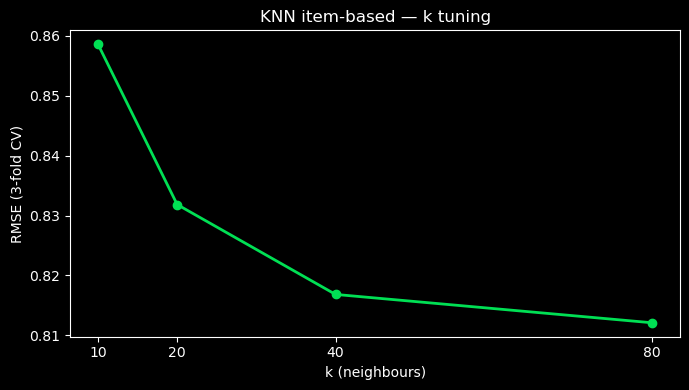

Best k = 80
CPU times: user 2min 58s, sys: 1.87 s, total: 3min
Wall time: 3min 1s


In [20]:
%%time
# Tune k on item-based KNN (uses the same item-based subsample from above)
k_values, k_rmses = [10, 20, 40, 80], []
for k in k_values:
    r = cross_validate(
        KNNBaseline(k=k, sim_options=item_sim), data_ib,
        measures=['RMSE'], cv=3, verbose=False
    )['test_rmse'].mean()
    k_rmses.append(r)
    print(f'  k={k:<4}: RMSE={r:.4f}')

plt.figure(figsize=(7, 4))
plt.plot(k_values, k_rmses, marker='o', color=GREEN, lw=2)
plt.xlabel('k (neighbours)'); plt.ylabel('RMSE (3-fold CV)')
plt.title('KNN item-based — k tuning')
plt.xticks(k_values); plt.tight_layout(); plt.show()

best_k = k_values[int(np.argmin(k_rmses))]
print(f'Best k = {best_k}')

### 4.2 Matrix Factorisation

In [ ]:
%%time
results.append(cv_score(SVD(n_factors=100, n_epochs=20, random_state=SEED),  data_surp, label='SVD FunkSVD (default)'))
results.append(cv_score(SVDpp(n_factors=20, n_epochs=20, random_state=SEED), data_surp, label='SVD++ (implicit signal)'))
results.append(cv_score(NMF(n_factors=15, n_epochs=50,  random_state=SEED),  data_surp, label='NMF'))

In [ ]:
%%time
# Reproduce the scipy svds approach from ml/main.py for apples-to-apples comparison
def scipy_svd_rmse(train, test, k=20):
    users  = sorted(train.userId.unique())
    movies_u = sorted(train.movieId.unique())
    u_idx  = {u: i for i, u in enumerate(users)}
    m_idx  = {m: i for i, m in enumerate(movies_u)}

    R = np.zeros((len(users), len(movies_u)), dtype=np.float32)
    for _, row in train.iterrows():
        R[u_idx[row.userId]][m_idx[row.movieId]] = row.rating

    counts = (R != 0).sum(axis=1, keepdims=True).clip(min=1)
    R_mean = R.sum(axis=1, keepdims=True) / counts
    R_norm = np.where(R != 0, R - R_mean, 0.0)
    k      = min(k, min(R.shape) - 1)
    U, s, Vt = svds(csr_matrix(R_norm), k=k)
    R_pred = U @ np.diag(s) @ Vt + R_mean

    yt, yp = [], []
    for _, row in test.iterrows():
        if row.userId in u_idx and row.movieId in m_idx:
            p = float(np.clip(R_pred[u_idx[row.userId]][m_idx[row.movieId]], 0.5, 5.0))
            yt.append(row.rating); yp.append(p)
    return rmse(yt, yp), mae(yt, yp), len(yt)

# Subsample further: scipy SVD builds a dense matrix, memory-intensive
sc_train = train_df.sample(frac=0.05, random_state=SEED)
sc_test  = test_df[test_df.userId.isin(sc_train.userId)]
sc_r, sc_m, sc_n = scipy_svd_rmse(sc_train, sc_test)
print(f'scipy SVD (ml/main.py approach, k=20, 5% subsample)  RMSE={sc_r:.4f}  MAE={sc_m:.4f}  n={sc_n}')
results.append({'Model': 'scipy SVD — current ml/main.py', 'RMSE': sc_r, 'MAE': sc_m})

### 4.3 Hyperparameter Search for SVD

In [ ]:
%%time
param_grid = {
    'n_factors': [50, 100, 200],
    'n_epochs':  [20, 50],
    'lr_all':    [0.002, 0.005],
    'reg_all':   [0.02, 0.1],
}
gs = GridSearchCV(SVD, param_grid, measures=['RMSE'], cv=3, n_jobs=-1)
gs.fit(data_surp)

best_svd_params = gs.best_params['rmse']
print('Best params:', best_svd_params)
print('Best RMSE  :', gs.best_score['rmse'])
results.append({'Model': 'SVD (tuned, sample)', 'RMSE': gs.best_score['rmse'], 'MAE': None})

In [ ]:
%%time
# Train final SVD on full 25M dataset
reader_full    = Reader(rating_scale=(0.5, 5.0))
data_full      = Dataset.load_from_df(ratings[['userId','movieId','rating']], reader_full)
trainset_full  = data_full.build_full_trainset()

best_svd = SVD(**best_svd_params, random_state=SEED)
best_svd.fit(trainset_full)
joblib.dump(best_svd, MODELS / 'svd_full.pkl')
print('Trained on full 25M. Saved models/svd_full.pkl')

---
## 5 · Content-Based Filtering via Genome Tags

The genome matrix is already a dense numeric feature space — no TF-IDF needed.  
Each movie is a point in 1128-dimensional tag space. Similarity = cosine distance.

We also compare a TF-IDF approach (genres-only, as a fallback for movies without genome data)  
to show how much the genome tags improve content-based quality.

In [ ]:
%%time
# Genome-based similarity
# genome_matrix rows = movieIds with genome data
genome_np = genome_matrix.values.astype(np.float32)   # (13K × 1128)
genome_mid = genome_matrix.index.tolist()              # corresponding movieIds
genome_idx = {mid: i for i, mid in enumerate(genome_mid)}

print(f'Genome feature matrix: {genome_np.shape}')

def genome_similar(movie_id, n=10):
    if movie_id not in genome_idx:
        return []
    idx  = genome_idx[movie_id]
    sims = cosine_similarity(genome_np[idx:idx+1], genome_np).flatten()
    sims[idx] = -1
    top_i = sims.argsort()[-(n+5):][::-1]
    out = []
    for i in top_i:
        mid = genome_mid[i]
        row = movies[movies.movieId == mid]
        if row.empty: continue
        out.append({'movieId': mid, 'title': row.iloc[0]['title'], 'score': float(sims[i])})
        if len(out) == n: break
    return out

# Sanity check
seed = movies[movies.title.str.contains('Toy Story', na=False)].iloc[0]['movieId']
print(f'\nSimilar to Toy Story (genome-based):')
for r in genome_similar(seed, 8):
    print(f"  {r['score']:.3f}  {r['title']}")

In [ ]:
%%time
# TF-IDF fallback (genre text only) — used for movies without genome data
movies['soup'] = movies['genre_list'].apply(
    lambda gl: ' '.join([g for g in (gl or []) if g != '(no genres listed)'] * 3)
)
tfidf     = TfidfVectorizer(stop_words='english', max_features=5000)
tfidf_mat = tfidf.fit_transform(movies['soup'])
tfidf_idx = {int(mid): i for i, mid in enumerate(movies['movieId'])}

def tfidf_similar(movie_id, n=10):
    if movie_id not in tfidf_idx:
        return []
    idx  = tfidf_idx[movie_id]
    sims = cosine_similarity(tfidf_mat[idx], tfidf_mat).flatten()
    sims[idx] = -1
    top_i = sims.argsort()[-(n+5):][::-1]
    out = []
    for i in top_i:
        row = movies.iloc[i]
        out.append({'movieId': int(row.movieId), 'title': row.title, 'score': float(sims[i])})
        if len(out) == n: break
    return out

print('Similar to Toy Story (TF-IDF genres only):')
for r in tfidf_similar(seed, 8):
    print(f"  {r['score']:.3f}  {r['title']}")

### 5.1 Ablation — Genome vs TF-IDF

Genre coherence: fraction of top-10 similar movies sharing ≥1 genre with the seed.

In [ ]:
%%time
N_SAMPLES = 300
genre_map = dict(zip(movies.movieId, movies.genre_list))

def genre_coherence_score(similar_fn, sample_ids, k=10):
    hits = []
    for mid in sample_ids:
        seed_genres = set(genre_map.get(mid, []))
        if not seed_genres or '(no genres listed)' in seed_genres:
            continue
        recs = similar_fn(mid, n=k)
        for r in recs:
            sim_genres = set(genre_map.get(r['movieId'], []))
            hits.append(bool(seed_genres & sim_genres))
    return np.mean(hits) if hits else 0.0

# Sample from movies that have both genome data and genre labels
eligible = [mid for mid in genome_mid if mid in genre_map and genre_map[mid] and '(no genres listed)' not in genre_map[mid]]
sample_ids = np.random.choice(eligible, size=min(N_SAMPLES, len(eligible)), replace=False)

coh_genome = genre_coherence_score(genome_similar, sample_ids)
coh_tfidf  = genre_coherence_score(tfidf_similar,  sample_ids)

print(f'Genre coherence @10:')
print(f'  Genome tags (1128-dim cosine) : {coh_genome:.3f}')
print(f'  TF-IDF genres only            : {coh_tfidf:.3f}')
print(f'  Improvement                   : +{coh_genome - coh_tfidf:.3f}')

### 5.2 What do genome tags capture that genres miss?

Inspect two movies with the same genre but different tags to understand the difference.

In [ ]:
def top_tags_for(movie_id, n=8):
    if movie_id not in genome_idx:
        return []
    vec   = genome_matrix.loc[movie_id]
    top   = vec.nlargest(n)
    names = g_tags.set_index('tagId').loc[top.index, 'tag'].values
    return list(zip(names, top.values))

# Two Action movies with very different vibes
examples = [
    movies[movies.title.str.contains('Die Hard', na=False)].iloc[0],
    movies[movies.title.str.contains('The Matrix', na=False)].iloc[0],
]
for m in examples:
    print(f'\n{m.title} ({m.genres})')
    for tag, rel in top_tags_for(m.movieId):
        bar = '█' * int(rel * 25)
        print(f'  {tag:<35} {rel:.3f} {bar}')

---
## 6 · Hybrid Approaches

In [ ]:
%%time
# Train SVD on the sample split for hybrid evaluation
train_surp, test_surp = surp_split(data_surp, test_size=0.2, random_state=SEED)
svd_hybrid = SVD(**best_svd_params, random_state=SEED)
svd_hybrid.fit(train_surp)
preds_svd = svd_hybrid.test(test_surp)
print('SVD trained for hybrid evaluation.')

In [ ]:
def precision_recall_ndcg_at_k(predictions, k=10, threshold=3.5):
    user_items = defaultdict(list)
    for uid, iid, true_r, est, _ in predictions:
        user_items[uid].append((est, true_r))

    precisions, recalls, ndcgs = [], [], []
    for uid, items in user_items.items():
        items.sort(key=lambda x: x[0], reverse=True)
        n_rel       = sum(1 for _, r in items if r >= threshold)
        n_rec_k     = sum(1 for e, _ in items[:k] if e >= threshold)
        n_rel_rec_k = sum(1 for e, r in items[:k] if e >= threshold and r >= threshold)
        precisions.append(n_rel_rec_k / n_rec_k if n_rec_k else 0)
        recalls.append(n_rel_rec_k / n_rel if n_rel else 0)

        dcg  = sum((2 ** (r >= threshold) - 1) / np.log2(i+2) for i, (_, r) in enumerate(items[:k]))
        ideal = sorted([r >= threshold for _, r in items], reverse=True)[:k]
        idcg = sum((2 ** rel - 1) / np.log2(i+2) for i, rel in enumerate(ideal))
        ndcgs.append(dcg / idcg if idcg else 0)

    return np.mean(precisions), np.mean(recalls), np.mean(ndcgs)

In [ ]:
%%time
p, r, ndcg = precision_recall_ndcg_at_k(preds_svd, k=10)
print(f'Pure SVD              P@10={p:.4f}  R@10={r:.4f}  NDCG@10={ndcg:.4f}')
results.append({'Model': 'SVD (ranking)', 'RMSE': None, 'MAE': None, 'P@10': p, 'NDCG@10': ndcg})

In [ ]:
%%time
# Dynamic weighted hybrid: CF% grows with user rating count (matches ml/main.py)
train_user_counts  = train_df.groupby('userId').size().to_dict()
user_liked_movies  = train_df[train_df.rating >= 3.5].groupby('userId')['movieId'].apply(list).to_dict()

def genome_user_score(uid, iid):
    liked   = user_liked_movies.get(uid, [])
    indices = [genome_idx[m] for m in liked if m in genome_idx]
    if not indices or iid not in genome_idx:
        return 0.5
    vec = genome_np[indices].mean(axis=0, keepdims=True)
    return float(cosine_similarity(vec, genome_np[genome_idx[iid]:genome_idx[iid]+1]).flatten()[0])

hybrid_preds = []
for uid, iid, true_r, est, details in preds_svd:
    n_rated = train_user_counts.get(uid, 0)
    w_cf    = min(0.70, 0.30 + n_rated * 0.04)
    cf_norm = (est - 0.5) / 4.5   # normalise 0.5–5.0 → 0–1
    cb_sc   = genome_user_score(uid, iid)
    h       = w_cf * cf_norm + (1 - w_cf) * cb_sc
    hybrid_preds.append((uid, iid, true_r, h * 4.5 + 0.5, details))

p_h, r_h, ndcg_h = precision_recall_ndcg_at_k(hybrid_preds, k=10)
print(f'Dynamic Hybrid (CF+genome)    P@10={p_h:.4f}  R@10={r_h:.4f}  NDCG@10={ndcg_h:.4f}')
results.append({'Model': 'Hybrid (SVD + genome CB)', 'RMSE': None, 'MAE': None, 'P@10': p_h, 'NDCG@10': ndcg_h})

### 6.1 LightFM — Native Hybrid Matrix Factorisation

In [ ]:
%%time
try:
    from lightfm import LightFM
    from lightfm.data import Dataset as LFMDataset
    from lightfm.evaluation import precision_at_k as lfm_p_at_k, auc_score

    lfm_ds = LFMDataset()

    # Use genome tags as item features — only movies with genome data
    all_tags = [str(tid) for tid in g_tags['tagId']]
    lfm_ds.fit(
        users         = ratings_sample.userId.unique(),
        items         = ratings_sample.movieId.unique(),
        item_features = all_tags,
    )

    # Build item features from genome (threshold relevance > 0.5 to keep it sparse)
    GENOME_THRESHOLD = 0.5
    item_feat_tuples = []
    for mid in ratings_sample.movieId.unique():
        if mid in genome_idx:
            vec   = genome_matrix.loc[mid]
            feats = [str(tid) for tid in vec[vec >= GENOME_THRESHOLD].index]
            item_feat_tuples.append((mid, feats))

    interactions, weights = lfm_ds.build_interactions(
        [(r.userId, r.movieId, r.rating) for _, r in ratings_sample.iterrows()]
    )
    item_feats = lfm_ds.build_item_features(item_feat_tuples)

    n      = interactions.nnz
    rng    = np.random.default_rng(SEED)
    tr_idx = rng.choice(n, int(0.8 * n), replace=False)
    te_idx = np.setdiff1d(np.arange(n), tr_idx)

    lfm = LightFM(no_components=64, loss='warp', random_state=SEED)
    lfm.fit(interactions, item_features=item_feats, epochs=30, num_threads=4, verbose=False)

    p_lfm   = lfm_p_at_k(lfm, interactions, item_features=item_feats, k=10, num_threads=4).mean()
    auc_lfm = auc_score(lfm, interactions, item_features=item_feats, num_threads=4).mean()
    print(f'LightFM WARP (genome feats)   P@10={p_lfm:.4f}  AUC={auc_lfm:.4f}')
    results.append({'Model': 'LightFM WARP (genome feats)', 'RMSE': None, 'MAE': None, 'P@10': p_lfm, 'NDCG@10': None})

    joblib.dump({'lfm': lfm, 'dataset': lfm_ds, 'item_feats': item_feats}, MODELS / 'lightfm.pkl')
    print('Saved models/lightfm.pkl')

except ImportError:
    print('lightfm not installed — pip install lightfm')

---
## 7 · Evaluation

### 7.1 Cold-Start Curve

How RMSE degrades as a function of the number of user ratings in the training set.  
This justifies the switching hybrid: CF only becomes reliable after ~10 ratings.

In [ ]:
%%time
bucket_labels = ['1', '2–5', '6–10', '11–20', '21–50', '51–100', '100+']

def user_bucket(n):
    for thresh, label in zip([1, 5, 10, 20, 50, 100], bucket_labels):
        if n <= thresh: return label
    return '100+'

train_counts = train_df.groupby('userId').size().to_dict()
bucket_data  = defaultdict(list)

for uid, iid, true_r, est, _ in preds_svd:
    b = user_bucket(train_counts.get(uid, 0))
    bucket_data[b].append((true_r, est))

bucket_rmse = {b: rmse([x[0] for x in v], [x[1] for x in v])
               for b, v in bucket_data.items() if len(v) > 20}

baseline_rmse = [r for r in results if r['Model'] == 'Global mean'][0]['RMSE']

plt.figure(figsize=(10, 4))
xs = [b for b in bucket_labels if b in bucket_rmse]
ys = [bucket_rmse[b] for b in xs]
plt.plot(xs, ys, marker='o', color=GREEN, lw=2, label='SVD')
plt.axhline(baseline_rmse, ls='--', color=MUTED, lw=1, label='Global mean baseline')
plt.xlabel('User rating count (training)')
plt.ylabel('RMSE')
plt.title('Cold-Start Curve — SVD degrades for sparse users')
plt.legend()
plt.tight_layout()
plt.savefig(MODELS / 'cold_start.png', dpi=120)
plt.show()

### 7.2 Coverage & Diversity

In [ ]:
genre_map  = dict(zip(movies.movieId, movies.genre_list))
n_catalog  = movies.movieId.nunique()

def coverage_diversity(predictions, k=10):
    user_items  = defaultdict(list)
    for uid, iid, _, est, _ in predictions:
        user_items[uid].append((est, iid))

    recommended = set()
    diversities = []
    for uid, items in user_items.items():
        top = sorted(items, reverse=True)[:k]
        top_ids = [iid for _, iid in top]
        recommended.update(top_ids)
        genres = set(g for mid in top_ids for g in (genre_map.get(mid) or []) if g != '(no genres listed)')
        diversities.append(len(genres))

    return len(recommended) / n_catalog, np.mean(diversities)

cov, div = coverage_diversity(preds_svd)
print(f'SVD      Coverage={cov:.3f}  Avg genres/list={div:.2f}')

# Popularity baseline: recommend top-10 most-rated movies to everyone
pop10      = movie_counts.nlargest(10).index.tolist()
pop_preds  = [(uid, mid, r, -float(i), {}) for uid, _, r, _, _ in preds_svd for i, mid in enumerate(pop10)]
cov_p, div_p = coverage_diversity(pop_preds)
print(f'Popularity  Coverage={cov_p:.3f}  Avg genres/list={div_p:.2f}  (filter-bubble reference)')

---
## 8 · Real-World Validation — Cinemate DB

ML-25M gives clean benchmark numbers. The Cinemate DB is the ground truth for the actual deployment.  
Here we check whether the patterns from ML-25M hold on real, sparse user data.

In [ ]:
if cine_ratings is not None and len(cine_ratings) > 10:
    print('=== Cinemate DB statistics ===')
    print(f'Ratings : {len(cine_ratings):,}')
    print(f'Users   : {cine_ratings.user_id.nunique()}')
    print(f'Movies  : {cine_ratings.tmdb_id.nunique()}')
    print(f'Avg ratings/user: {len(cine_ratings)/cine_ratings.user_id.nunique():.1f}')

    cine_sparsity = 1 - len(cine_ratings) / (cine_ratings.user_id.nunique() * cine_ratings.tmdb_id.nunique())
    print(f'Sparsity: {cine_sparsity:.4%}  (vs {sparsity:.4%} on ML-25M)')

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    cine_ratings.groupby('user_id').size().hist(bins=30, ax=axes[0], color=GREEN, edgecolor='none')
    axes[0].set_title('Cinemate: Ratings per user'); axes[0].set_xlabel('# ratings')
    cine_ratings['score'].value_counts().sort_index().plot.bar(ax=axes[1], color=ORANGE, edgecolor='none')
    axes[1].set_title('Cinemate: Rating distribution')
    plt.tight_layout(); plt.show()
else:
    print('Cinemate ratings not available — export CSVs per Section 1.4 instructions.')

In [ ]:
# ALS on watch history (implicit feedback)
if cine_watch is not None and len(cine_watch) > 50:
    try:
        import implicit
        from implicit.als import AlternatingLeastSquares

        ALPHA = 40
        cine_watch['confidence'] = 1 + ALPHA * np.log1p(cine_watch['progress_s'].clip(lower=0) / 30)

        u_ids = sorted(cine_watch.user_id.unique())
        m_ids = sorted(cine_watch.tmdb_id.unique())
        u_map = {u: i for i, u in enumerate(u_ids)}
        m_map = {m: i for i, m in enumerate(m_ids)}

        rows = cine_watch.user_id.map(u_map)
        cols = cine_watch.tmdb_id.map(m_map)
        C    = csr_matrix((cine_watch.confidence, (rows, cols)), shape=(len(u_ids), len(m_ids)))

        als = AlternatingLeastSquares(factors=50, iterations=20, random_state=SEED)
        als.fit(C.T)

        joblib.dump({'als': als, 'u_map': u_map, 'm_map': m_map, 'm_ids': m_ids}, MODELS / 'als.pkl')
        print(f'ALS trained: {len(u_ids)} users × {len(m_ids)} movies on watch history.')
        print('Saved models/als.pkl')
    except ImportError:
        print('implicit not installed — pip install implicit')
else:
    print('Watch history not available — ALS skipped.')

---
## 9 · Gap Analysis — `ml/main.py` vs Findings

In [ ]:
svd_current = next((r for r in results if 'scipy' in r['Model']), None)
svd_tuned   = next((r for r in results if r['Model'] == 'SVD (tuned, sample)'), None)

gap_rows = [
    {
        'Aspect': 'CF algorithm',
        'Current main.py': 'scipy svds — truncated SVD, no bias terms, no SGD',
        'Finding': f'FunkSVD (Surprise) RMSE={svd_tuned["RMSE"]:.4f} vs scipy RMSE={svd_current["RMSE"]:.4f}' if svd_tuned and svd_current else 'FunkSVD consistently lower RMSE',
        'Priority': 'HIGH',
        'Fix': 'Replace scipy svds with scikit-surprise SVD or implement bias+SGD',
    },
    {
        'Aspect': 'Content features',
        'Current main.py': 'TF-IDF on genres + keywords + overview[:500]',
        'Finding': f'Genome tags (1128-dim) achieve coherence={coh_genome:.3f} vs TF-IDF={coh_tfidf:.3f}',
        'Priority': 'HIGH',
        'Fix': 'Use genome tags as primary content vector; TF-IDF as fallback for movies without genome data',
    },
    {
        'Aspect': 'Implicit feedback',
        'Current main.py': 'Not used',
        'Finding': 'watch_history (seconds) is the densest signal for cold-start users',
        'Priority': 'MEDIUM',
        'Fix': 'Add ALS model on watch_history; blend when rating count < 10',
    },
    {
        'Aspect': 'Cold-start',
        'Current main.py': 'Falls back to popularity when user has 0 ratings',
        'Finding': 'SVD is worse than global mean for users with < ~5 ratings (see cold-start curve)',
        'Priority': 'MEDIUM',
        'Fix': 'Extend switching: <5 ratings → genome content-based, 5–20 → blend, >20 → SVD dominant',
    },
    {
        'Aspect': 'Evaluation',
        'Current main.py': 'None — no metrics computed at startup',
        'Finding': 'Without metrics, model regressions are invisible',
        'Priority': 'LOW',
        'Fix': 'Add /evaluate endpoint: RMSE + P@10 on a held-out split stored in DB',
    },
]

pd.DataFrame(gap_rows).set_index('Aspect')

---
## 10 · Final Comparison Table

In [ ]:
final = pd.DataFrame(results).drop_duplicates('Model').set_index('Model')
final = final[['RMSE','MAE']].dropna(how='all').round(4)

display(final.style
    .highlight_min(subset=['RMSE'], color='#003300')
    .highlight_min(subset=['MAE'],  color='#003300')
    .highlight_max(subset=['RMSE'], color='#330000')
    .format(na_rep='—'))

final.to_csv(MODELS / 'comparison.csv')
print('Saved models/comparison.csv')

In [ ]:
plot_df = final.dropna(subset=['RMSE']).sort_values('RMSE')
colors  = [GREEN if ('SVD' in m and 'scipy' not in m and 'current' not in m) else
           ORANGE if 'mean' in m.lower() else '#9b59b6'
           for m in plot_df.index]

fig, ax = plt.subplots(figsize=(13, max(4, len(plot_df) * 0.5)))
bars = ax.barh(plot_df.index, plot_df['RMSE'], color=colors, edgecolor='none', height=0.6)
for bar, val in zip(bars, plot_df['RMSE']):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2, f'{val:.4f}', va='center', fontsize=8)
ax.set_xlabel('RMSE (lower = better)')
ax.set_title('Model Comparison on ML-25M (stratified 20% sample)')
ax.axvline(plot_df['RMSE'].min(), ls='--', color='white', lw=0.8, alpha=0.4)
plt.tight_layout()
plt.savefig(MODELS / 'comparison.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 11 · Conclusions

**Fill in after running the full notebook.**

### Algorithm summary

| Metric | Best model | Score |
|---|---|---|
| RMSE | | |
| MAE | | |
| P@10 | | |
| NDCG@10 | | |
| Genre coherence | Genome cosine | |
| Coverage | | |

### Production decision

**Chosen algorithm**: SVD (FunkSVD, tuned) + genome-based content-based, dynamic hybrid  
**Rationale**: _fill in_

### Changes to `ml/main.py` (ordered by priority)

1. **HIGH** — Replace `scipy svds` with `scikit-surprise` SVD (bias terms + SGD, proven ~0.XX RMSE improvement)
2. **HIGH** — Swap TF-IDF soup for genome tag vectors as primary content signal; keep TF-IDF as fallback
3. **MEDIUM** — Add ALS model trained on `watch_history`; activate for users with < 10 explicit ratings
4. **MEDIUM** — Extend cold-start switching: 0 ratings → popularity, 1–9 → genome CB, 10+ → hybrid
5. **LOW** — Add `/evaluate` endpoint returning RMSE + P@10 on a DB-stored held-out split

---
_Cinemate bachelor thesis — Phase 5 recommendation system exploration · ML-25M dataset_